# 2. Building Worlds

TidalPy has three kinds of world:

- a layered terrestrial world (`LayeredWorld`): an ordered stack of solid and liquid layers,
- a gas giant (`GasGiantWorld`): a layered world whose outer layer is a gas envelope,
- a star (`StarWorld`): no layers and no interior structure, described by its effective temperature and luminosity.

`build_world` returns the matching type from the config's `type` field. This notebook builds one of each, runs the geometric and thermal calculations they share, and then solves a terrestrial world's interior structure and plots it.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.structures_x.configs import build_world

terrestrial = build_world("earth_simple")     # -> LayeredWorld
gas_giant   = build_world("jupiter_simple")   # -> GasGiantWorld
star        = build_world("sol")              # -> StarWorld

for w in (terrestrial, gas_giant, star):
    print(f"{type(w).__name__:16} name={w.name:14} type={w.world_type:12} "
          f"R={w.radius:.3e} m  M={w.mass:.3e} kg")


LayeredWorld     name=Earth-Simple   type=terrestrial  R=6.371e+06 m  M=5.972e+24 kg
GasGiantWorld    name=Jupiter-Simple type=gasgiant     R=6.991e+07 m  M=1.898e+27 kg
StarWorld        name=Sol            type=star         R=6.957e+08 m  M=1.988e+30 kg


C:\venvs\tpy13\Lib\site-packages\TidalPy\__init__.py:58: TidalPyDeprecationWarning: TidalPy's backend is changing: the classic modules (structures, tides, RadialSolver, rheology, ...) are deprecated and will be replaced by the new C++ backend (structures_x, Tides_x, RadialSolver_x, rheology_x, ...) in a future major release. New development happens in the `_x` modules. See the porting guide at https://tidalpy.readthedocs.io/en/latest/future_structure.html. Silence this message with warnings.filterwarnings('ignore', category=TidalPy.exceptions.TidalPyDeprecationWarning).
  _warnings.warn(


## Shared World Calculations

Every world reports its bulk geometry and derived quantities: volume and surface area from its radius, mean density from mass and volume, and surface gravity and escape velocity from mass and radius.

In [2]:
def bulk_report(w):
    return {
        "mean density (kg/m^3)": w.calc_mean_density(),
        "surface gravity (m/s^2)": w.calc_surface_gravity(),
        "escape velocity (m/s)": w.calc_escape_velocity(),
        "surface area (m^2)": w.calc_surface_area(w.radius),
    }

print(f"{'quantity':26} {'terrestrial':>14} {'gas giant':>14} {'star':>14}")
keys = list(bulk_report(terrestrial))
reps = [bulk_report(w) for w in (terrestrial, gas_giant, star)]
for k in keys:
    print(f"{k:26} " + " ".join(f"{rep[k]:14.4g}" for rep in reps))


quantity                      terrestrial      gas giant           star
mean density (kg/m^3)                5513           1326           1410
surface gravity (m/s^2)              9.82          25.92          274.2
escape velocity (m/s)           1.119e+04       6.02e+04      6.177e+05
surface area (m^2)              5.101e+14      6.142e+16      6.082e+18


## Solving the Equation of State

`solve_eos()` integrates gravity, pressure, enclosed mass, and moment of inertia radially outward from the center, using each layer's equation of state. After the solve, `get_density`, `get_gravity`, and `get_pressure` return the profile at any radius, scalar or array, and `get_moment_of_inertia` returns the solved value.

The world here is `earth_prem`, a three-layer Earth (solid inner core, liquid outer core, mantle plus crust) built from a PREM radial profile.


In [3]:
earth = build_world("earth_prem")
print("layers:", earth.num_layers)
print("moment of inertia before solve:", earth.get_moment_of_inertia(), "kg m^2  (uniform-density estimate)")

earth.solve_eos()

moi = earth.get_moment_of_inertia()
moi_factor = moi / (earth.mass * earth.radius**2)
print("moment of inertia after solve :", moi, "kg m^2")
print(f"normalized moment of inertia I/MR^2 = {moi_factor:.4f}  (Earth is about 0.33)")


layers: 3
moment of inertia before solve: 9.696053442080002e+37 kg m^2  (uniform-density estimate)
moment of inertia after solve : 8.026688010107385e+37 kg m^2
normalized moment of inertia I/MR^2 = 0.3311  (Earth is about 0.33)


Density and pressure both rise sharply toward the center. Gravity peaks near the core-mantle boundary rather than at the center, because most of the mass lies outside small radii.

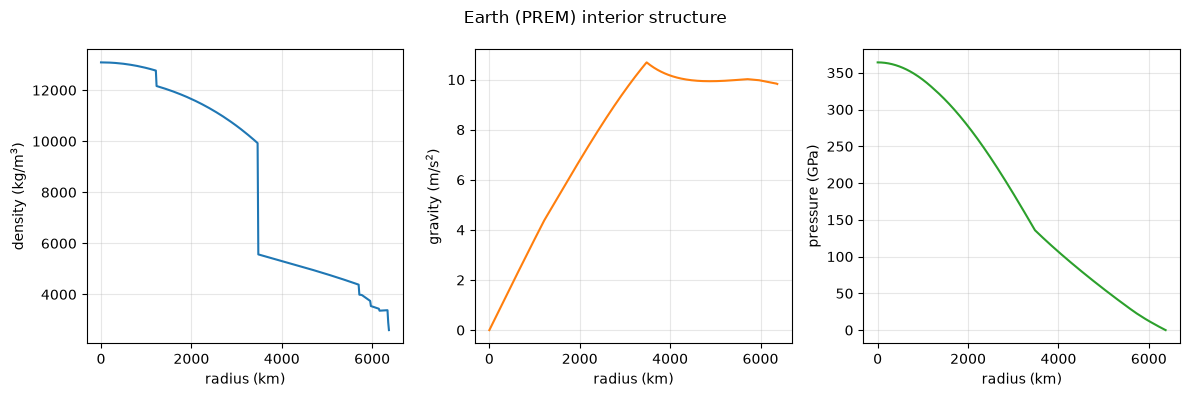

In [4]:
radii = np.linspace(1.0, earth.radius, 400)
radii_km = radii / 1.0e3

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(radii_km, earth.get_density(radii))
axes[0].set_ylabel("density (kg/m$^3$)")
axes[1].plot(radii_km, earth.get_gravity(radii), color="tab:orange")
axes[1].set_ylabel("gravity (m/s$^2$)")
axes[2].plot(radii_km, earth.get_pressure(radii) / 1.0e9, color="tab:green")
axes[2].set_ylabel("pressure (GPa)")
for ax in axes:
    ax.set_xlabel("radius (km)")
    ax.grid(alpha=0.3)
fig.suptitle("Earth (PREM) interior structure")
fig.tight_layout()
plt.show()


## Stellar Luminosity and Planet Heating

A star carries no interior. It is described by its effective temperature and its luminosity, tied together by the Stefan-Boltzmann law. The luminosity sets the flux reaching a planet, which falls off as the inverse square of distance, and the planet turns that flux into an equilibrium temperature.


In [5]:
print(f"Sun effective temperature: {star.effective_temperature:.0f} K")
print(f"Sun luminosity           : {star.luminosity:.4e} W")

AU = 1.495978707e11        # one astronomical unit in meters
flux_1au = star.luminosity / (4.0 * np.pi * AU**2)
print(f"flux at 1 AU             : {flux_1au:.1f} W/m^2  (the solar constant)")

t_eq = terrestrial.calc_equilibrium_temperature(flux_1au)
print(f"Earth equilibrium temperature at 1 AU: {t_eq:.1f} K")


Sun effective temperature: 5772 K
Sun luminosity           : 3.8280e+26 W
flux at 1 AU             : 1361.2 W/m^2  (the solar constant)
Earth equilibrium temperature at 1 AU: 254.6 K


## Recap

- `build_world` returns a `LayeredWorld`, `GasGiantWorld`, or `StarWorld` from the config's `type`.
- Every world shares bulk calculations: mean density, surface gravity, escape velocity, surface area.
- A layered world's `solve_eos()` integrates its interior. `get_density`, `get_gravity`, `get_pressure`, and `get_moment_of_inertia` then describe the structure. Earth's solved `I/MR^2` lands near 0.33.
- A star's luminosity follows from its effective temperature and sets the flux, and hence the equilibrium temperature, of a planet at a given distance.

Next: `03_save_load` saves and loads worlds and systems as TOML and as binary files.
